Optimal number of components: 10
Average MSE with 10 components: 0.08568438092825299


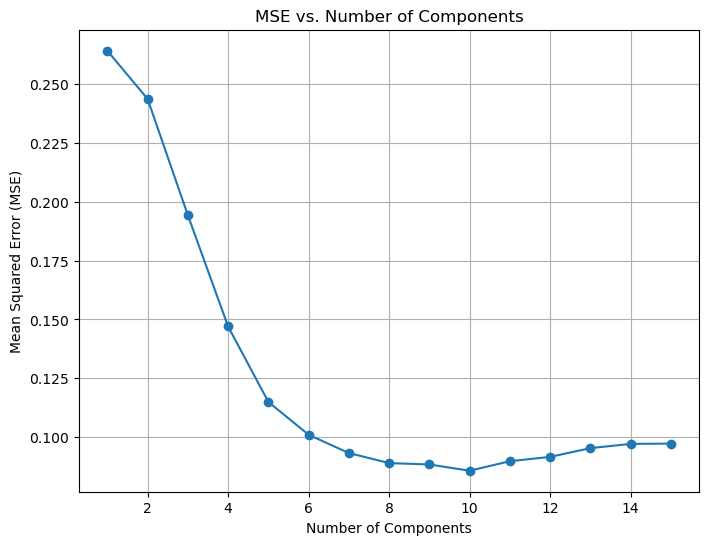

In [3]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Specify the path to your CSV file
csv_file_path = r'C:\Users\say70\Desktop\Nx\2020\7_16\Processing pipeline\LUM_VI\7_16_2020_LUM_average_vis_values.csv'

# Load your data from the CSV file
data = pd.read_csv(csv_file_path)

# Define the list of variable names based on your CSV columns
variable_names = [
    'NDVI', 'GNDVI', 'DVI', 'EVI', 'EVI2', 'MARI', 'CHLRE', 'CHLGR', 'SAVI', 'SAVI2',
    'MSAVI','OSAVI','TSAVI', 'MSR', 'MCARI', 'MCARI/OSAVI', 'PVI', 'SR', 'TCI', 'WDRI', 'egreen']

# Extract the vegetation variables and the target variable (Vegetation Fraction) using the variable names
x = data[variable_names].values
y = data['Vegetation Fraction'].values

# Filter out rows with missing values (NaN)
valid_rows = ~np.isnan(x).any(axis=1)
x_filtered = x[valid_rows]
y_filtered = y[valid_rows]

# Standardize the input variables (x_filtered) and the target variable (y_filtered)
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x_std = scaler_x.fit_transform(x_filtered)
y_std = scaler_y.fit_transform(y_filtered.reshape(-1, 1)).flatten()

# Initialize variables to store cross-validation results
best_component = None
best_mse = float('inf')
mse_list = []

# Create an empty list to store MSE values for each component
mse_per_component = []

# Define the range of components to test
components_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Perform k-fold cross-validation for each number of components
kf = KFold(n_splits=5, shuffle=True, random_state=0)  # Using 5-fold cross-validation
for n_components in components_range:
    mse_list = []  # Reset the MSE list for each component
    for train_index, val_index in kf.split(x_std):
        x_train_fold, x_val_fold = x_std[train_index], x_std[val_index]
        y_train_fold, y_val_fold = y_std[train_index], y_std[val_index]

        # Fit PLSR model
        pls = PLSRegression(n_components=n_components)
        pls.fit(x_train_fold, y_train_fold)

        # Predict on validation set
        y_pred = pls.predict(x_val_fold)

        # Calculate mean squared error
        mse = mean_squared_error(y_val_fold, y_pred)
        mse_list.append(mse)

    # Calculate average MSE across folds for this component
    avg_mse = np.mean(mse_list)
    mse_per_component.append(avg_mse)

    # Check if this number of components results in a better MSE
    if avg_mse < best_mse:
        best_mse = avg_mse
        best_component = n_components

print(f"Optimal number of components: {best_component}")
print(f"Average MSE with {best_component} components: {best_mse}")

# Plot the MSE for different numbers of components
plt.figure(figsize=(8, 6))
plt.plot(components_range, mse_per_component, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs. Number of Components')
plt.grid(True)
plt.show()


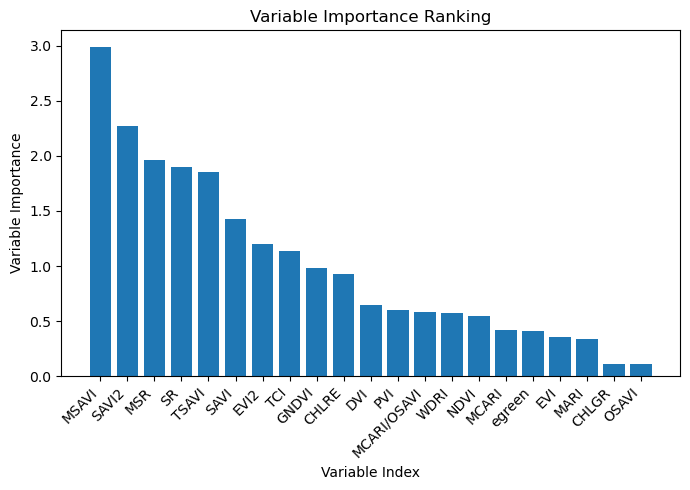

Variable Rankings:
MSAVI: Rank 1
SAVI2: Rank 2
MSR: Rank 3
SR: Rank 4
TSAVI: Rank 5
SAVI: Rank 6
EVI2: Rank 7
TCI: Rank 8
GNDVI: Rank 9
CHLRE: Rank 10
DVI: Rank 11
PVI: Rank 12
MCARI/OSAVI: Rank 13
WDRI: Rank 14
NDVI: Rank 15
MCARI: Rank 16
egreen: Rank 17
EVI: Rank 18
MARI: Rank 19
CHLGR: Rank 20
OSAVI: Rank 21


In [6]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Specify the path to your CSV file
csv_file_path = r'C:\Users\say70\Desktop\NX\2020\7_16\Processing pipeline\LUM_VI\7_16_2020_LUM_average_vis_values.csv'

# Load your data from the CSV file
data = pd.read_csv(csv_file_path)

# Define the list of variable names based on your CSV columns
variable_names = [
    'NDVI', 'GNDVI', 'DVI', 'EVI', 'EVI2', 'MARI', 'CHLRE', 'CHLGR', 'SAVI', 'SAVI2',
    'MSAVI','OSAVI','TSAVI', 'MSR', 'MCARI', 'MCARI/OSAVI', 'PVI', 'SR', 'TCI', 'WDRI', 'egreen'
]

# Extract the vegetation variables and the target variable (Vegetation Fraction) using the variable names
X = data[variable_names].values
y = data['Vegetation Fraction'].values

# Replace missing values (NaN) with zeros
X = np.nan_to_num(X)

# Standardize the input variables (X) and the target variable (y)
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_std = scaler_x.fit_transform(X)
y_std = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Fit the PLSR model
n_components = 10  # Number of PLSR components to use
pls = PLSRegression(n_components=n_components)
pls.fit(X_std, y_std)

# Calculate variable importance scores
variable_importance = np.abs(pls.coef_).mean(axis=0)

# Rank the variables
sorted_indices = np.argsort(variable_importance)[::-1]

# Plot a histogram of variable importance scores
plt.figure(figsize=(7, 5))  # Adjust the figure size
plt.bar(range(1, len(sorted_indices) + 1), variable_importance[sorted_indices])
plt.xlabel('Variable Index')
plt.ylabel('Variable Importance')
plt.title('Variable Importance Ranking')
plt.xticks(range(1, len(sorted_indices) + 1), [variable_names[i] for i in sorted_indices], rotation=45, ha='right')
plt.tight_layout()  # Ensures the labels fit within the figure
plt.show()

# Print variable rankings
variable_ranking = {variable_names[i]: rank + 1 for rank, i in enumerate(sorted_indices)}
print("Variable Rankings:")
for variable, rank in variable_ranking.items():
    print(f"{variable}: Rank {rank}")
